Train: (1070, 9) (1070,)
Test: (268, 9) (268,)


,Features,Coefficients
0,age,256.98
1,sex,-18.59
2,bmi,337.09
3,children,425.28
4,smoker,23651.13
5,region_northeast,459.59
6,region_northwest,88.91
7,region_southeast,-198.28
8,region_southwest,-350.21
9,INTERCEPT,-12390.80


MAE score: 4208
MAPE score: 42 %
R2 score: 0.742
****************************************
MAE score: 4181
MAPE score: 47 %
R2 score: 0.784


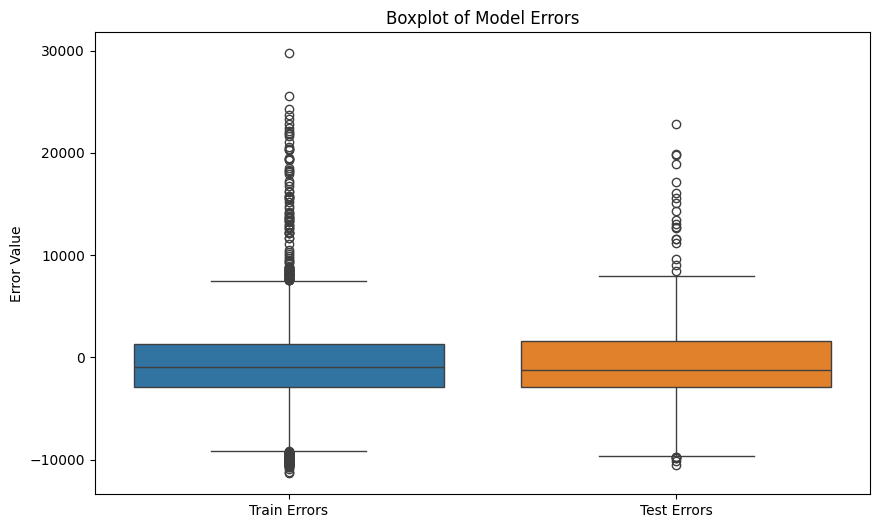

Original number of features: 9
Number of features after polynomial transformation: 54
R2 score: 0.867
MAE score: 2728
MAPE score: 30 %
R2 score: 0.867
MAE score: 2861
MAPE score: 31 %
R2 score: 0.863


/Users/konstantingeneralov/IDE/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.964e+09, tolerance: 1.544e+07
  model = cd_fast.enet_coordinate_descent(
/Users/konstantingeneralov/IDE/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.216e+09, tolerance: 1.544e+07
  model = cd_fast.enet_coordinate_descent(


In [3]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #разделение выборки

ins = pd.read_csv('/Users/konstantingeneralov/IDE/Data/insurance.csv', sep=',')
ins_df = ins.copy()

#кодируем бинарные категориальные признаки
ins_df['smoker'] = ins_df['smoker'].apply(lambda x: 0 if x == 'no' else 1)
ins_df['sex'] = ins_df['sex'].apply(lambda x: 0 if x == 'female' else 1)
#оставшиеся категориальные признаки кодируем с помощью OneHot
ins_df = pd.get_dummies(ins_df)
#замним true на 1, false на 0
ins_df['region_northwest'] = ins_df['region_northwest'].apply(lambda x: 1 if x == True else 0)
ins_df['region_southeast'] = ins_df['region_southeast'].apply(lambda x: 1 if x == True else 0)
ins_df['region_southwest'] = ins_df['region_southwest'].apply(lambda x: 1 if x == True else 0)

features = ins_df.drop('charges', axis=1).columns
X, y = ins_df[features], ins_df['charges']

#Разделяем выборку на тренировочную и тестовую в соотношении 70/30
#Устанавливаем random_state для воспроизводимости результатов 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Выводим результирующие размеры таблиц
print('Train:', X_train.shape, y_train.shape)
print('Test:', X_test.shape, y_test.shape)

#Создаём объект класса LinearRegression
lr_model = linear_model.LinearRegression()
#Обучаем модель по МНК
lr_model.fit(X_train, y_train)

#Составляем таблицу из признаков и их коэффициентов
w_df = pd.DataFrame({'Features': features, 'Coefficients': lr_model.coef_})
#Составляем строчку таблицы со свободным членом
intercept_df =pd.DataFrame({'Features': ['INTERCEPT'], 'Coefficients': lr_model.intercept_})
coef_df = pd.concat([w_df, intercept_df], ignore_index=True)
#выводим таблицу округленную до 2 знаков после запятой
coef_df['Coefficients'] = coef_df['Coefficients'].round(2)
display(coef_df)

#Рассчитываем MAE
y_predict_full_train = lr_model.predict(X_train)
print('MAE score: {:.0f}'.format(metrics.mean_absolute_error(y_train, y_predict_full_train)))
#Рассчитываем MAPE
print('MAPE score: {:.0f} %'.format(metrics.mean_absolute_percentage_error(y_train, y_predict_full_train) * 100))
#Рассчитываем коэффициент детерминации
print('R2 score: {:.3f}'.format(metrics.r2_score(y_train, y_predict_full_train)))

print('****************************************')

#Рассчитываем MAE
y_predict_full_test = lr_model.predict(X_test)
print('MAE score: {:.0f}'.format(metrics.mean_absolute_error(y_test, y_predict_full_test)))
#Рассчитываем MAPE
print('MAPE score: {:.0f} %'.format(metrics.mean_absolute_percentage_error(y_test, y_predict_full_test) * 100))
#Рассчитываем коэффициент детерминации
print('R2 score: {:.3f}'.format(metrics.r2_score(y_test, y_predict_full_test)))

#Постройте диаграмму boxplot для визуализации ошибок модели линейной регрессии на тестовой выборке и тренировочной выборке для сравнения
train_errors = y_train - y_predict_full_train
test_errors = y_test - y_predict_full_test
error_df = pd.DataFrame({'Train Errors': train_errors, 'Test Errors': test_errors})
plt.figure(figsize=(10, 6))
sns.boxplot(data=error_df)
plt.title('Boxplot of Model Errors')
plt.ylabel('Error Value')
plt.show()

#Нормализуем тренировочную и тестовую выборки с помощью min-max-нормализации (MinMaxScaler) Расчетаем параметры нормализации (fit) произведите на тренировочной выборке.

scaler = preprocessing.MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#сгенерируйте полиномиальные признаки степени 2
poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print('Original number of features:', X_train.shape[1])
print('Number of features after polynomial transformation:', X_train_poly.shape[1])

#Обучите модель линейной регрессии на полиномиальных признаках
lr_model_poly = linear_model.LinearRegression()
lr_model_poly.fit(X_train_poly, y_train)

#r2 на тестовой выборке
y_predict_poly = lr_model_poly.predict(X_test_poly)
print('R2 score: {:.3f}'.format(metrics.r2_score(y_test, y_predict_poly)))

#Выведите значения коэффициентов полученной модели. Посмотрите на степени коэффициентов.
coef_poly = pd.DataFrame({'Features': poly.get_feature_names_out(input_features=X_train.columns), 'Coefficients': lr_model_poly.coef_})
coef_poly = coef_poly.sort_values(by='Coefficients', ascending=False)
#display(coef_poly)

#Постройте линейную регрессию с L1-регуляризацией (Lasso) на полиномиальных признаках
lasso_model = linear_model.Lasso(alpha=0.1)
lasso_model.fit(X_train_poly, y_train)

#Постройте линейную регрессию с L1-регуляризацией (Lasso) на полиномиальных признаках. 
# В качестве параметра alpha используйте значение по умолчанию, параметр max_iter установите в значение 2000.
lasso_model = linear_model.Lasso(alpha=0.1, max_iter=2000)
lasso_model.fit(X_train_poly, y_train)

# Предсказания Lasso на тестовой выборке
y_predict_lasso = lasso_model.predict(X_test_poly)

#mae на тестовой выборке
print('MAE score: {:.0f}'.format(metrics.mean_absolute_error(y_test, y_predict_lasso)))
#mape на тестовой выборке
print('MAPE score: {:.0f} %'.format(metrics.mean_absolute_percentage_error(y_test, y_predict_lasso) * 100))
#r2 на тестовой выборке
print('R2 score: {:.3f}'.format(metrics.r2_score(y_test, y_predict_lasso))) 

#Постройте линейную регрессию с L2-регуляризацией на полиномиальных признаках. 
# В качестве параметра alpha используйте значение по умолчанию.
ridge_model = linear_model.Ridge()
ridge_model.fit(X_train_poly, y_train)

# Предсказания Ridge на тестовой выборке
y_predict_ridge = ridge_model.predict(X_test_poly)

#mae на тестовой выборке
print('MAE score: {:.0f}'.format(metrics.mean_absolute_error(y_test, y_predict_ridge)))
#mape на тестовой выборке
print('MAPE score: {:.0f} %'.format(metrics.mean_absolute_percentage_error(y_test, y_predict_ridge) * 100))
#r2 на тестовой выборке
print('R2 score: {:.3f}'.format(metrics.r2_score(y_test, y_predict_ridge)))

#display(ins_df.head(), ins_df.info(), ins_df.describe(include='all'))